In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

pd.options.display.max_columns = None

In [2]:
load_dotenv()
cleaned_csv_path = os.getenv('cleaned_csv_path')
df = pd.read_csv(cleaned_csv_path)

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df.shape

(120000, 12)

In [5]:
# feature extraction
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday

In [6]:
# feature creation
df['engagement_rate'] = (df['likes']+df['comments'])/df['views']
df['likes_per_view'] = df['likes']/df['views']
df['comments_per_view'] = df['comments']/df['views']
df['watch_time_per_view'] = df['watch_time_minutes']/df['views']

In [7]:
# dropping non-relavent columns
df.drop(columns=['video_id','date'],inplace=True)

In [8]:
# one hot encoding
df = pd.get_dummies(df, columns=['category','device','country'], drop_first=True, dtype=int)

In [9]:
df

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,year,month,day,weekday,engagement_rate,likes_per_view,comments_per_view,watch_time_per_view,category_Entertainment,category_Gaming,category_Lifestyle,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
0,9936,1221.0,320.0,26497.214184,2.862137,228086,203.178237,2024,9,24,1,0.155093,0.122886,0.032206,2.666789,1,0,0,0,0,0,1,0,0,0,1,0,0
1,10017,642.0,346.0,15209.747445,23.738069,736015,140.880508,2024,9,22,6,0.098632,0.064091,0.034541,1.518393,0,1,0,0,0,0,0,1,1,0,0,0,0
2,10097,1979.0,187.0,57332.658498,26.200634,240534,360.134008,2024,11,21,3,0.214519,0.195999,0.018520,5.678187,0,0,0,0,0,0,1,0,1,0,0,0,0
3,10034,1191.0,242.0,31334.517771,11.770340,434482,224.638261,2025,1,28,1,0.142814,0.118696,0.024118,3.122834,1,0,0,0,0,1,0,0,0,0,0,1,0
4,9889,1858.0,477.0,15665.666434,6.635854,42030,165.514388,2025,4,28,0,0.236121,0.187886,0.048235,1.584151,0,0,0,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,9853,1673.0,147.0,42075.704885,25.490195,210818,280.986396,2024,12,14,5,0.184715,0.169796,0.014919,4.270345,0,0,0,0,0,0,0,1,0,0,0,0,1
119996,10128,1709.0,63.0,57563.703040,16.229133,878860,354.612981,2024,7,13,5,0.174961,0.168740,0.006220,5.683620,0,0,0,1,0,0,0,0,0,0,0,1,0
119997,10267,700.0,274.0,27549.714659,23.822365,576756,203.643106,2024,6,10,0,0.094867,0.068180,0.026687,2.683327,0,0,0,0,1,0,0,1,1,0,0,0,0
119998,10240,1616.0,106.0,56967.384382,7.753099,585138,351.525811,2024,12,22,6,0.168164,0.157812,0.010352,5.563221,0,0,0,1,0,1,0,0,0,0,0,1,0


In [11]:
df.to_csv('model_data.csv', index=False)   

In [10]:
X = df.drop(columns=['ad_revenue_usd'])
y = df['ad_revenue_usd']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# standard scaler to scale down values
scaler = StandardScaler()

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=61)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# cross validation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# eval metrics
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error


In [13]:
def cv_r2(model, X, y):
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    return scores.mean()

In [14]:
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)

    return r2, mae, rmse

In [15]:
results = []

In [16]:
# Linear Regressor

lr = LinearRegression()
lr_cv2= cv_r2(lr, X_train_scaled, y_train)

In [17]:
lr.fit(X_train_scaled, y_train)
lr_r2, lr_mae, lr_rmse = evaluate(lr, X_test_scaled, y_test)

results.append(['Linear Regression', lr_cv2, lr_r2, lr_mae, lr_rmse])

In [18]:
ridge_params = {'alpha':[0.01, 0.1, 1, 10, 100]}

ridge_search = RandomizedSearchCV(Ridge(), param_distributions=ridge_params, cv=10, scoring='r2')

ridge_search.fit(X_train_scaled, y_train)

,estimator,Ridge()
,param_distributions,"{'alpha': [0.01, 0.1, ...]}"
,n_iter,10
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [19]:
best_ridge = ridge_search.best_estimator_

In [20]:
ridge_cv = cv_r2(best_ridge, X_train_scaled, y_train)
ridge_r2, ridge_mae, ridge_rmse = evaluate(best_ridge, X_test_scaled, y_test)

results.append(['Ridge', ridge_cv, ridge_r2, ridge_mae, ridge_rmse])

In [41]:
rf_params = {'n_estimators':[100, 200],
             'max_depth':[5 ,10 ,None],
             'min_samples_split':[5, 10],
             'min_samples_leaf':[10 ,25, 50]
            }

rf_search = RandomizedSearchCV(RandomForestRegressor() ,param_distributions=rf_params ,n_iter=10, cv= 5, scoring='r2', n_jobs=-1)

rf_search.fit(X_train_scaled, y_train)

TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

In [ ]:
rf_search.best_params_

In [ ]:
best_rf = rf_search.best_estimator_

In [21]:
best_rf = RandomForestRegressor(n_estimators= 200,
 min_samples_split=10,
 min_samples_leaf= 10,
 max_depth= 10,
random_state=61)

best_rf.fit(X_train_scaled, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
rf_cv = cv_r2(best_rf, X_train_scaled, y_train)
rf_r2, rf_mae, rf_rmse = evaluate(best_rf, X_test_scaled, y_test)

In [23]:
results.append(['Random Forest' ,rf_cv ,rf_r2 ,rf_mae ,rf_rmse])

In [26]:
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth = 4, random_state=61)

gbr.fit(X_train_scaled, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [27]:
gbr_cv = cv_r2(gbr, X_train_scaled, y_train)
gbr_r2, gbr_mae, gbr_rmse = evaluate(gbr, X_test_scaled, y_test)

In [28]:
results.append(['Gradient Boosting Regressor' ,gbr_cv ,gbr_r2 ,gbr_mae ,gbr_rmse])

In [49]:
xgb = XGBRegressor(random_state=61, objective='reg:squarederror')

xgb_params = { 'n_estimators':[100,200],
               'max_depth':[3,5,7],
               'learning_rate':[0.02, 0.05, 0.1],
               'subsample':[0.8, 1.0]
             }

xgb_search = RandomizedSearchCV(xgb, param_distributions=xgb_params, n_iter=10, cv=5, scoring='r2', n_jobs=-1)
xgb_search.fit(X_train_scaled, y_train)

## xgb_search.best_params_ {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05} ##

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'learning_rate': [0.02, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [50]:
xgb_search.best_params_

{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}

In [53]:
best_xgb = xgb_search.best_estimator_

xgb_cv = cv_r2(best_xgb, X_train_scaled, y_train)
xgb_r2, xgb_mae, xgb_rmse = evaluate(best_xgb, X_test_scaled, y_test)

results.append(['XGBoost',xgb_cv, xgb_r2, xgb_mae, xgb_rmse])

In [24]:
best_xgb = XGBRegressor(random_state=61,subsample= 1.0, n_estimators= 200, max_depth= 3, learning_rate= 0.05, objective='reg:squarederror')#2

best_xgb.fit(X_train_scaled, y_train)
xgb_cv = cv_r2(best_xgb, X_train_scaled, y_train)
xgb_r2, xgb_mae, xgb_rmse = evaluate(best_xgb, X_test_scaled, y_test)

results.append(['XGBoost',xgb_cv, xgb_r2, xgb_mae, xgb_rmse])

In [29]:
results#2

[['Linear Regression',
  np.float64(0.9502131917908901),
  0.9504740177544083,
  3.253855176906138,
  13.78408228217952],
 ['Ridge',
  np.float64(0.9502132262871802),
  0.9504740065196875,
  3.2537192836335103,
  13.784083845604403],
 ['Random Forest',
  np.float64(0.9498697272694947),
  0.9498158895832088,
  3.7951523021860485,
  13.875365217428588],
 ['XGBoost',
  np.float64(0.9500817358757265),
  0.9503273611319016,
  3.616714580324653,
  13.804475947611834],
 ['Gradient Boosting Regressor',
  np.float64(0.9500628035936544),
  0.950174551701555,
  3.5979714508081173,
  13.825693204236561]]

In [67]:
results

[['Linear Regression',
  np.float64(0.9502079995161292),
  0.9504740177544083,
  3.253855176906138,
  13.78408228217952],
 ['Ridge',
  np.float64(0.9502080226649465),
  0.9504740065196875,
  3.2537192836335103,
  13.784083845604403],
 ['Random Forest',
  np.float64(0.9498955463966399),
  0.9497613067319078,
  3.7936711892354813,
  13.882908951558903],
 ['XGBoost',
  np.float64(0.9500817358757265),
  0.9503273611319016,
  3.616714580324653,
  13.804475947611834],
 ['Gradient Boosting Regressor',
  np.float64(0.9422717571985884),
  0.9424622809961535,
  7.252979229623742,
  14.857222541703818]]

In [36]:
import pickle as pk

In [23]:
with open('best_lr.pkl', 'wb') as f:
    pk.dump(lr, f)

In [24]:
with open('best_ridge.pkl', 'wb') as f:
    pk.dump(best_ridge, f)

In [40]:
with open('best_rf.pkl', 'wb') as f:
    pk.dump(best_rf, f)

In [34]:
with open('best_xgb.pkl', 'wb') as f:
    pk.dump(best_xgb, f)

In [35]:
with open('best_gbr.pkl', 'wb') as f:
    pk.dump(gbr, f)

In [32]:
model_comparision = pd.DataFrame(results, columns=['Model','CV_R2','Test_R2','MAE','RMSE'])

model_comparision.sort_values(by=['Test_R2','RMSE','MAE'], ascending=False)

,Model,CV_R2,Test_R2,MAE,RMSE
0,Linear Regression,0.950213,0.950474,3.253855,13.784082
1,Ridge,0.950213,0.950474,3.253719,13.784084
3,XGBoost,0.950082,0.950327,3.616715,13.804476
4,Gradient Boosting Regressor,0.950063,0.950175,3.597971,13.825693
2,Random Forest,0.949870,0.949816,3.795152,13.875365


In [76]:
# Linear Regression , Ridge same R2 on test.
# MAE is smaller for Ridge.
# RMSE is almost same too.

# Linear Regression and Ridge Regression demonstrated nearly identical performance across all evaluation metrics. 

In [33]:
model_comparision.to_csv('model_results.csv',index=False)

In [20]:
coef_df = pd.DataFrame({'Feature':X.columns,'Coefficient':lr.coef_})

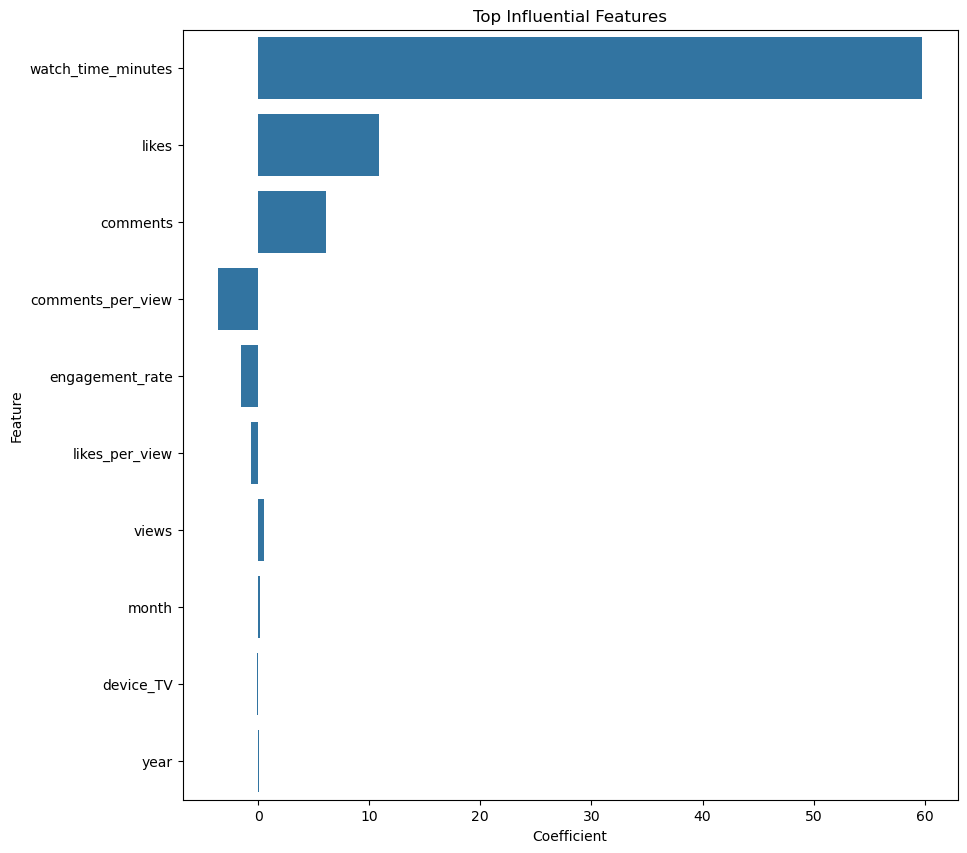

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = coef_df.sort_values(by='Coefficient', key=abs, ascending=False).head(10)

plt.figure(figsize=(10,10))

sns.barplot(data=top_features,x='Coefficient',y='Feature')

plt.title('Top Influential Features')
plt.show()

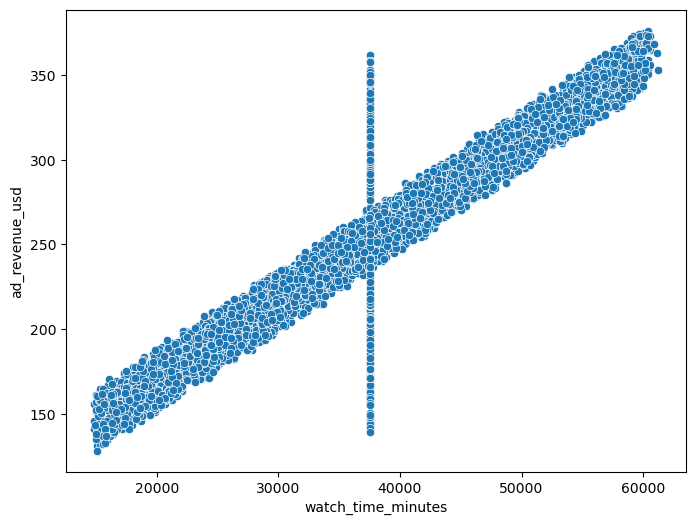

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='watch_time_minutes',
    y='ad_revenue_usd',
    data=df.sample(5000)
)

plt.show()

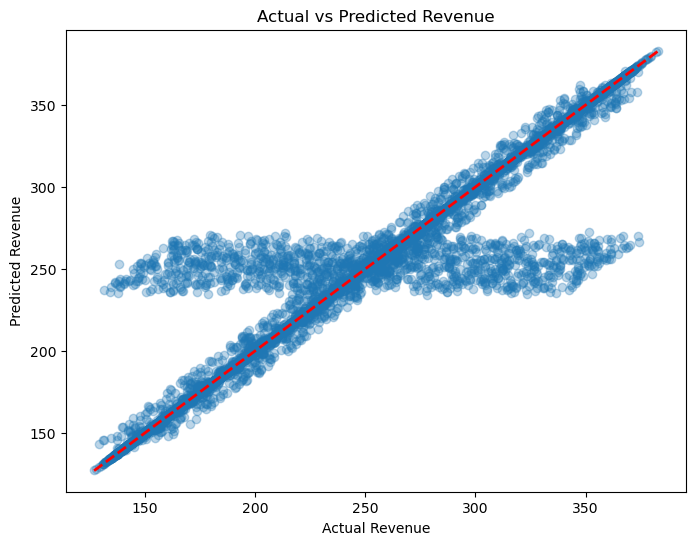

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()

In [32]:
pred.min(), pred.max()

(np.float64(127.39331020200841), np.float64(383.1384232245019))

In [34]:
y_test.min(), y_test.max()

(126.96220541228226, 382.7682540396426)

In [33]:
pd.Series(pred).describe()

count    24000.000000
mean       252.617488
std         60.390203
min        127.393310
25%        202.653936
50%        252.354670
75%        302.968888
max        383.138423
dtype: float64

In [37]:
pk.dump(X.columns.tolist(),open("features.pkl", "wb"))

In [38]:
pk.dump(scaler,open("scaler.pkl", "wb"))